# FOLD-TOMO-01b: Trace-Sufficient Reverse Fold Engine — SAFE RUN VERSION

**Research group:** Nexus Fold Tomography  
**Short code:** `FOLD-TOMO`  
**Notebook ID:** `FOLD-TOMO-01b`  
**Engine:** Trace-Sufficient Reverse Fold Engine (`TSRFE`)  
**Primary pin:** `448 Nyquist Pin`  
**Primary theorem:** Dyadic Terminal Tomography Theorem (`DTT`)

This is the cleaned, safer version of the first notebook. It avoids hang-risk by:

- using a minimal robust `lucas_offsets()` implementation;
- keeping expensive random controls optional;
- keeping full-size rank tests isolated;
- adding clear checkpoints after every proof stage;
- avoiding large uncontrolled display output.

Core collapse:

$$
\boxed{\text{Forward collapse hides address; reverse recovery restores address by reading shape.}}
$$

Core operator:

$$
d_i^{(\ell+1)}=\left|d_{i+1}^{(\ell)}-d_i^{(\ell)}\right|
$$

Parity shadow:

$$
x_i^{(\ell+1)}=x_i^{(\ell)}\oplus x_{i+1}^{(\ell)}
$$

Operator form:

$$
x^{(\ell)}=(I+E)^\ell x^{(0)}
$$

Lucas mask:

$$
x_i^{(\ell)}=\bigoplus_{j\subseteq\ell}x_{i+j}^{(0)}
$$


## 0. Naming Lock

Use these names across ChatGPT, Gemini, Kimi, Claude, and future notes.

| Object | Name | Short code |
|---|---|---|
| Research branch | Nexus Fold Tomography | `FOLD-TOMO` |
| This notebook | Trace-Sufficient Reverse Fold Engine — Safe Run | `FOLD-TOMO-01b` |
| Main exact system | Rule-90 parity shadow of decimal fold | `Parity Shadow` |
| Main structural pin | Level 448 eight-point 64-grid probe | `448 Nyquist Pin` |
| Terminal theorem | Dyadic terminal rows are residue-class parity checks | `DTT` |
| Inversion method | Linear parity tomography + nonlinear weight filtering | `TSRFE` |

The purpose of this notebook is not just visualization. It is a proof harness.


In [1]:
# Cell 1 — Setup

import sys
import subprocess
import importlib.util
from pathlib import Path
from collections import defaultdict
import math
import random
import time

required = ["numpy", "matplotlib", "mpmath"]
missing = [pkg for pkg in required if importlib.util.find_spec(pkg) is None]
if missing:
    print("Installing missing packages:", missing)
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])

import numpy as np
import matplotlib.pyplot as plt
import mpmath as mp

plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.grid"] = True

print("Setup complete.")


Setup complete.


## 1. Seed: First 2048 Fractional Digits of $\pi$

The convention here is **first 2048 digits after the decimal point**.

That gives the known checksum:

$$
S_0^{(10)}=9338.
$$


In [2]:
# Cell 2 — Load first 2048 fractional digits of pi

def pi_fractional_digits(n=2048, guard=50):
    """Return the first n fractional decimal digits of pi."""
    mp.mp.dps = n + guard
    s = str(mp.pi)
    return s.split(".")[1][:n]

N = 2048
digits = pi_fractional_digits(N)
decimal_seed = [int(c) for c in digits]

print("N:", N)
print("first 32 digits:", digits[:32])
print("decimal sum S0:", sum(decimal_seed))

assert len(digits) == 2048
assert sum(decimal_seed) == 9338
print("Seed check passed.")


N: 2048
first 32 digits: 14159265358979323846264338327950
decimal sum S0: 9338
Seed check passed.


## 2. Decimal Difference Fold and Parity Shadow

Decimal fold:

$$
d_i^{(\ell+1)}=\left|d_{i+1}^{(\ell)}-d_i^{(\ell)}\right|
$$

Parity projection:

$$
x_i^{(\ell)}=d_i^{(\ell)}\bmod2
$$

Exact identity:

$$
|a-b|\bmod2=(a+b)\bmod2=a\oplus b
$$


In [3]:
# Cell 3 — Fold builders

def decimal_difference_rows(seed):
    rows = [list(seed)]
    cur = list(seed)
    while len(cur) > 1:
        cur = [abs(b - a) for a, b in zip(cur, cur[1:])]
        rows.append(cur)
    return rows

def xor_rows(seed_bits):
    rows = [list(seed_bits)]
    cur = list(seed_bits)
    while len(cur) > 1:
        cur = [a ^ b for a, b in zip(cur, cur[1:])]
        rows.append(cur)
    return rows

parity_seed = [d & 1 for d in decimal_seed]

t0 = time.time()
decimal_rows = decimal_difference_rows(decimal_seed)
xor_lattice = xor_rows(parity_seed)
print(f"Built decimal and XOR lattices in {time.time() - t0:.3f} seconds.")

assert len(decimal_rows) == N
assert len(xor_lattice) == N
print("Fold rows built.")


Built decimal and XOR lattices in 0.146 seconds.
Fold rows built.


In [4]:
# Cell 4 — Verify exact parity shadow

parity_shadow_ok = True
bad = None

for level in range(N):
    projected = [(v & 1) for v in decimal_rows[level]]
    if projected != xor_lattice[level]:
        parity_shadow_ok = False
        bad = level
        break

print("Parity shadow exact across all levels:", parity_shadow_ok)
if bad is not None:
    print("First mismatch level:", bad)

assert parity_shadow_ok


Parity shadow exact across all levels: True


## 3. Glyph Reader Metrics

For the binary/XOR lattice:

$$
N_\ell=\text{row length}
$$

$$
S_\ell=\sum_i x_i^{(\ell)}
$$

$$
\rho_\ell=\frac{S_\ell}{N_\ell}
$$

$$
R_\ell=S_\ell-\frac{N_\ell}{2}
$$

Exact half-density lock:

$$
R_\ell=0.
$$


In [5]:
# Cell 5 — Trace metrics

def trace_metrics(rows):
    N_vals = np.array([len(r) for r in rows], dtype=int)
    S_vals = np.array([sum(r) for r in rows], dtype=int)
    rho = S_vals / N_vals
    R = S_vals - N_vals / 2.0
    return {
        "N": N_vals,
        "S": S_vals,
        "rho": rho,
        "R": R,
        "dS": np.diff(S_vals),
        "dR": np.diff(R),
        "locks": [i for i, val in enumerate(R) if val == 0],
    }

binary_trace = trace_metrics(xor_lattice)
decimal_N = np.array([len(r) for r in decimal_rows], dtype=int)
decimal_S = np.array([sum(r) for r in decimal_rows], dtype=int)

print("Decimal S0:", decimal_S[0])
print("Decimal S13:", decimal_S[13])
print("Amplitude collapse by level 13:", (decimal_S[0] - decimal_S[13]) / decimal_S[0])
print()
print("Parity S0:", binary_trace["S"][0])
print("Parity R0:", binary_trace["R"][0])
print("R=0 lock count:", len(binary_trace["locks"]))
print("First 15 locks:", binary_trace["locks"][:15])

assert decimal_S[0] == 9338
assert decimal_S[13] == 1092


Decimal S0: 9338
Decimal S13: 1092
Amplitude collapse by level 13: 0.8830584707646177

Parity S0: 1034
Parity R0: 10.0
R=0 lock count: 44
First 15 locks: [110, 300, 342, 376, 448, 496, 556, 640, 688, 854, 898, 932, 954, 1076, 1260]


## 4. Verified Structural Locks

The core checks:

$$
N_{448}=1600,\quad S_{448}=800,\quad R_{448}=0
$$

$$
N_{512}=1536,\quad S_{512}=764,\quad R_{512}=-4
$$

Terminal:

$$
x^{(2046)}=[1,1],\qquad x^{(2047)}=[0].
$$


In [6]:
# Cell 6 — Verify core locks

def summarize_level(level):
    row = xor_lattice[level]
    n = len(row)
    s = sum(row)
    r = s - n / 2
    print(f"ℓ={level:4d}: N={n:4d}, S={s:4d}, rho={s/n:.6f}, R={r}")
    if n <= 32:
        print("  row:", row)

for level in [0, 13, 110, 448, 512, 2032, 2040, 2044, 2046, 2047]:
    summarize_level(level)

assert binary_trace["N"][448] == 1600
assert binary_trace["S"][448] == 800
assert binary_trace["R"][448] == 0

assert binary_trace["N"][512] == 1536
assert binary_trace["S"][512] == 764
assert binary_trace["R"][512] == -4

assert xor_lattice[2046] == [1, 1]
assert xor_lattice[2047] == [0]

print("Core lock checks passed.")


ℓ=   0: N=2048, S=1034, rho=0.504883, R=10.0
ℓ=  13: N=2035, S=1006, rho=0.494349, R=-11.5
ℓ= 110: N=1938, S= 969, rho=0.500000, R=0.0
ℓ= 448: N=1600, S= 800, rho=0.500000, R=0.0
ℓ= 512: N=1536, S= 764, rho=0.497396, R=-4.0
ℓ=2032: N=  16, S=   8, rho=0.500000, R=0.0
  row: [0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 1, 1, 0, 1, 1]
ℓ=2040: N=   8, S=   4, rho=0.500000, R=0.0
  row: [1, 0, 0, 1, 0, 1, 0, 1]
ℓ=2044: N=   4, S=   2, rho=0.500000, R=0.0
  row: [1, 1, 0, 0]
ℓ=2046: N=   2, S=   2, rho=1.000000, R=1.0
  row: [1, 1]
ℓ=2047: N=   1, S=   0, rho=0.000000, R=-0.5
  row: [0]
Core lock checks passed.


## 5. Robust Lucas Offsets

This is the cell that previously caused trouble. This version is deliberately small and safe.

For each level:

$$
\text{mask size}=2^{\operatorname{popcount}(\ell)}.
$$

Largest test below:

$$
\ell=2047 \Rightarrow 2^{11}=2048
$$

which is tiny.


In [7]:
# Cell 7 — Robust Lucas offset generator

def popcount(n):
    # Compatible with older Python versions.
    return bin(int(n)).count("1")

def lucas_offsets(level):
    """
    Return all offsets j such that j is a bit-subset of level.

    Equivalent:
        binomial(level, j) odd
        j & ~level == 0
        j ⊆ level
    """
    level = int(level)
    offsets = [0]
    bit = 1
    n = level

    while n:
        if n & 1:
            # Safe: doubles list only popcount(level) times.
            offsets = offsets + [o + bit for o in offsets]
        n >>= 1
        bit <<= 1

    return offsets

test_levels = [110, 448, 512, 640, 2040, 2044, 2046, 2047]

for level in test_levels:
    offsets = lucas_offsets(level)
    print(
        f"level={level:4d}, "
        f"binary={level:b}, "
        f"popcount={popcount(level):2d}, "
        f"mask_size={len(offsets):4d}, "
        f"expected={2**popcount(level):4d}"
    )
    print(" offsets:", offsets[:16], "..." if len(offsets) > 16 else "")
    print()

assert lucas_offsets(448) == [0, 64, 128, 192, 256, 320, 384, 448]
assert lucas_offsets(512) == [0, 512]
assert len(lucas_offsets(2047)) == 2048

print("Lucas offset cell complete.")


level= 110, binary=1101110, popcount= 5, mask_size=  32, expected=  32
 offsets: [0, 2, 4, 6, 8, 10, 12, 14, 32, 34, 36, 38, 40, 42, 44, 46] ...

level= 448, binary=111000000, popcount= 3, mask_size=   8, expected=   8
 offsets: [0, 64, 128, 192, 256, 320, 384, 448] 

level= 512, binary=1000000000, popcount= 1, mask_size=   2, expected=   2
 offsets: [0, 512] 

level= 640, binary=1010000000, popcount= 2, mask_size=   4, expected=   4
 offsets: [0, 128, 512, 640] 

level=2040, binary=11111111000, popcount= 8, mask_size= 256, expected= 256
 offsets: [0, 8, 16, 24, 32, 40, 48, 56, 64, 72, 80, 88, 96, 104, 112, 120] ...

level=2044, binary=11111111100, popcount= 9, mask_size= 512, expected= 512
 offsets: [0, 4, 8, 12, 16, 20, 24, 28, 32, 36, 40, 44, 48, 52, 56, 60] ...

level=2046, binary=11111111110, popcount=10, mask_size=1024, expected=1024
 offsets: [0, 2, 4, 6, 8, 10, 12, 14, 16, 18, 20, 22, 24, 26, 28, 30] ...

level=2047, binary=11111111111, popcount=11, mask_size=2048, expected=204

## 6. Lucas Direct Row Verification

Closed form:

$$
x_i^{(\ell)}
=
\bigoplus_{j\subseteq\ell}x_{i+j}^{(0)}.
$$


In [8]:
# Cell 8 — Verify Lucas direct computation against recursive lattice

def row_from_lucas(seed_bits, level):
    offsets = lucas_offsets(level)
    row_len = len(seed_bits) - level
    out = []
    for i in range(row_len):
        v = 0
        for j in offsets:
            v ^= seed_bits[i + j]
        out.append(v)
    return out

check_levels = [0, 1, 2, 3, 13, 110, 448, 512, 640, 1024, 2040, 2044, 2046, 2047]

for level in check_levels:
    direct = row_from_lucas(parity_seed, level)
    assert direct == xor_lattice[level], f"Lucas direct mismatch at level {level}"

print("Lucas direct rows match recursive XOR lattice at all checked levels.")


Lucas direct rows match recursive XOR lattice at all checked levels.


## 7. Dyadic Terminal Tomography Theorem

For:

$$
N=2^m,\qquad \ell_k=N-2^k
$$

the row is:

$$
x_i^{(N-2^k)}
=
\bigoplus_{q=0}^{2^{m-k}-1}x_{i+q2^k}^{(0)}.
$$

Each terminal row is a residue-class checksum modulo $2^k$.


In [9]:
# Cell 9 — Dyadic terminal theorem

def dyadic_terminal_row_from_seed(seed_bits, k):
    N = len(seed_bits)
    modulus = 1 << k
    out = []
    for i in range(modulus):
        v = 0
        for q in range(i, N, modulus):
            v ^= seed_bits[q]
        out.append(v)
    return out

m = int(math.log2(N))
assert 2**m == N

for k in range(0, m):
    level = N - (1 << k)
    theorem_row = dyadic_terminal_row_from_seed(parity_seed, k)
    lattice_row = xor_lattice[level]
    ok = theorem_row == lattice_row
    print(f"k={k:2d}, level={level:4d}, row_len={len(lattice_row):4d}, theorem_match={ok}")
    if k <= 4:
        print(" row:", lattice_row)
    assert ok

print("Dyadic terminal tomography theorem verified for k=0..10.")


k= 0, level=2047, row_len=   1, theorem_match=True
 row: [0]
k= 1, level=2046, row_len=   2, theorem_match=True
 row: [1, 1]
k= 2, level=2044, row_len=   4, theorem_match=True
 row: [1, 1, 0, 0]
k= 3, level=2040, row_len=   8, theorem_match=True
 row: [1, 0, 0, 1, 0, 1, 0, 1]
k= 4, level=2032, row_len=  16, theorem_match=True
 row: [0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 1, 1, 0, 1, 1]
k= 5, level=2016, row_len=  32, theorem_match=True
k= 6, level=1984, row_len=  64, theorem_match=True
k= 7, level=1920, row_len= 128, theorem_match=True
k= 8, level=1792, row_len= 256, theorem_match=True
k= 9, level=1536, row_len= 512, theorem_match=True
k=10, level=1024, row_len=1024, theorem_match=True
Dyadic terminal tomography theorem verified for k=0..10.


## 8. GF(2) Rank Engine

Each parity equation is stored as a Python integer bitmask. This makes rank computation fast and memory-light.

A linear probe row is:

$$
\langle c,x\rangle=y
$$

over $GF(2)$.


In [10]:
# Cell 10 — GF(2) rank engine

def masks_for_level(N, level):
    offsets = lucas_offsets(level)
    masks = []
    for i in range(N - level):
        mask = 0
        for j in offsets:
            mask |= 1 << (i + j)
        masks.append(mask)
    return masks

def gf2_rank_int(rows):
    """
    Rank of integer bitmask rows over GF(2).
    Sparse Gaussian elimination using Python integers.
    """
    basis = {}
    for row in rows:
        x = int(row)
        while x:
            pivot = x.bit_length() - 1
            if pivot in basis:
                x ^= basis[pivot]
            else:
                basis[pivot] = x
                break
    return len(basis)

print("Rank engine ready.")


Rank engine ready.


In [11]:
# Cell 11 — Rank collapse: dyadic + 448

t0 = time.time()

dyadic_masks = []
for k in range(0, m):
    level = N - (1 << k)
    dyadic_masks.extend(masks_for_level(N, level))

masks_448 = masks_for_level(N, 448)
masks_512 = masks_for_level(N, 512)

rank_dyadic = gf2_rank_int(dyadic_masks)
rank_448 = gf2_rank_int(masks_448)
rank_dyadic_448 = gf2_rank_int(dyadic_masks + masks_448)
rank_dyadic_512 = gf2_rank_int(dyadic_masks + masks_512)
rank_all = gf2_rank_int(dyadic_masks + masks_448 + masks_512)

elapsed = time.time() - t0

print(f"Rank computations complete in {elapsed:.3f} seconds.")
print("Number of dyadic terminal rows:", len(dyadic_masks))
print("rank(dyadic) =", rank_dyadic)
print("rank(448) =", rank_448)
print("rank(dyadic + 448) =", rank_dyadic_448)
print("rank(dyadic + 512) =", rank_dyadic_512)
print("rank(dyadic + 448 + 512) =", rank_all)
print("Remaining degrees after dyadic + 448:", N - rank_dyadic_448)

assert rank_dyadic == 1024
assert rank_dyadic_448 == 1600
assert N - rank_dyadic_448 == 448


Rank computations complete in 0.009 seconds.
Number of dyadic terminal rows: 2047
rank(dyadic) = 1024
rank(448) = 1600
rank(dyadic + 448) = 1600
rank(dyadic + 512) = 1536
rank(dyadic + 448 + 512) = 1600
Remaining degrees after dyadic + 448: 448


## 9. Reverse Entropy of the 448 Pin

Since:

$$
448=256+128+64,
$$

the operator factors:

$$
(I+E)^{448}
=
(I+E^{256})(I+E^{128})(I+E^{64}).
$$

Each factor $I+E^s$ reverses by choosing $s$ boundary bits.

Total boundary entropy:

$$
256+128+64=448.
$$


In [12]:
# Cell 12 — One shift-XOR reverse demonstration

def reverse_one_shift_xor(y, shift, boundary):
    """
    Reverse y_i = x_i XOR x_{i+shift}.
    boundary = first shift bits of x.
    """
    assert len(boundary) == shift
    x = list(boundary) + [0] * len(y)
    for i, yi in enumerate(y):
        x[i + shift] = x[i] ^ yi
    return x

x_true = [1,0,1,1,0,0,1,0]
shift = 2
y = [x_true[i] ^ x_true[i+shift] for i in range(len(x_true)-shift)]
x_rec = reverse_one_shift_xor(y, shift=shift, boundary=x_true[:shift])

print("x_true:", x_true)
print("y:", y)
print("boundary:", x_true[:shift])
print("x_rec:", x_rec)

assert x_rec == x_true
print("One shift-XOR reverse demo passed.")


x_true: [1, 0, 1, 1, 0, 0, 1, 0]
y: [0, 1, 1, 1, 1, 0]
boundary: [1, 0]
x_rec: [1, 0, 1, 1, 0, 0, 1, 0]
One shift-XOR reverse demo passed.


## 10. Nonlinear Weight Constraints

Linear rows:

$$
A_\ell x=y_\ell
$$

Weight rows:

$$
\operatorname{wt}(A_\ell x)=S_\ell
$$

The row-sum constraints are nonlinear pseudo-Boolean constraints. These are the next decoder layer.


In [14]:
# Cell 13 — R=0 and R!=0 levels

zero_R_levels = binary_trace["locks"]
nonzero_R_levels = [i for i, R in enumerate(binary_trace["R"]) if R != 0]

print("Total levels:", len(binary_trace["R"]))
print("R=0 levels:", len(zero_R_levels))
print("R!=0 levels:", len(nonzero_R_levels))
print("Check total:", len(zero_R_levels) + len(nonzero_R_levels))

print("First 20 R=0:", zero_R_levels[:20])
print("Last 20 R=0:", zero_R_levels[-20:])

assert len(zero_R_levels) == 44
assert len(nonzero_R_levels) == len(binary_trace["R"]) - len(zero_R_levels)

# Optional: count only an interior analysis window if needed
interior_start = 20
interior_end = 1800
interior_R = binary_trace["R"][interior_start:interior_end]
interior_zero = [interior_start + i for i, R in enumerate(interior_R) if R == 0]
interior_nonzero = [interior_start + i for i, R in enumerate(interior_R) if R != 0]

print()
print(f"Interior window ℓ={interior_start}..{interior_end-1}")
print("Interior R=0:", len(interior_zero))
print("Interior R!=0:", len(interior_nonzero))

Total levels: 2048
R=0 levels: 44
R!=0 levels: 2004
Check total: 2048
First 20 R=0: [110, 300, 342, 376, 448, 496, 556, 640, 688, 854, 898, 932, 954, 1076, 1260, 1266, 1288, 1318, 1326, 1348]
Last 20 R=0: [1670, 1744, 1754, 1772, 1776, 1786, 1830, 1850, 1942, 1944, 1968, 1970, 1990, 1998, 2002, 2022, 2030, 2032, 2040, 2044]

Interior window ℓ=20..1799
Interior R=0: 30
Interior R!=0: 1750


## 11. Small-N Weight-Trace Rigidity

The full $2048$ inversion is large, so first test the weight trace on small systems:

$$
\mathcal W(x)
=
\left(
\operatorname{wt}((I+E)^\ell x)
\right)_{\ell=0}^{N-1}.
$$


In [15]:
# Cell 14 — Small-N weight-trace equivalence classes

def bits_from_int(n, width):
    return [(n >> i) & 1 for i in range(width)]

def weight_trace(bits):
    rows = xor_rows(bits)
    return tuple(sum(r) for r in rows)

def enumerate_weight_trace_classes(width=16):
    classes = defaultdict(list)
    for n in range(1 << width):
        bits = bits_from_int(n, width)
        classes[weight_trace(bits)].append(n)
    sizes = [len(v) for v in classes.values()]
    return classes, sizes

for width in [8, 10, 12, 14, 16]:
    t0 = time.time()
    classes, sizes = enumerate_weight_trace_classes(width)
    elapsed = time.time() - t0
    total = 1 << width
    unique = sum(1 for s in sizes if s == 1)
    print(
        f"N={width:2d}: total={total:6d}, "
        f"distinct_traces={len(classes):6d}, "
        f"unique_classes={unique:6d}, "
        f"max_class={max(sizes):4d}, "
        f"mean_class={sum(sizes)/len(sizes):.3f}, "
        f"time={elapsed:.2f}s"
    )


N= 8: total=   256, distinct_traces=   121, unique_classes=    10, max_class=   4, mean_class=2.116, time=0.00s
N=10: total=  1024, distinct_traces=   465, unique_classes=    28, max_class=   4, mean_class=2.202, time=0.01s
N=12: total=  4096, distinct_traces=  1804, unique_classes=    44, max_class=   4, mean_class=2.271, time=0.03s
N=14: total= 16384, distinct_traces=  7245, unique_classes=   128, max_class=   8, mean_class=2.261, time=0.14s
N=16: total= 65536, distinct_traces= 29301, unique_classes=   186, max_class=   8, mean_class=2.237, time=0.74s


## 12. Optional Random Controls

Random controls prove the carrier is universal. They are optional because full $2048$ controls are slower.

Set:

```python
RUN_RANDOM_CONTROLS = True
```

to run them.


In [16]:
# Cell 15 — Optional random controls

RUN_RANDOM_CONTROLS = False
RANDOM_TRIALS = 20

def random_binary_seed(N, rng=random):
    return [rng.randrange(2) for _ in range(N)]

def lock_count_for_seed(bits):
    rows = xor_rows(bits)
    trace = trace_metrics(rows)
    return len(trace["locks"])

if RUN_RANDOM_CONTROLS:
    rng = random.Random(12345)
    t0 = time.time()
    random_lock_counts = [lock_count_for_seed(random_binary_seed(N, rng)) for _ in range(RANDOM_TRIALS)]
    elapsed = time.time() - t0

    pi_lock_count = len(binary_trace["locks"])
    mu = np.mean(random_lock_counts)
    sigma = np.std(random_lock_counts, ddof=1) if RANDOM_TRIALS > 1 else float("nan")

    print("pi lock count:", pi_lock_count)
    print("random controls:")
    print("  trials =", RANDOM_TRIALS)
    print("  mean =", mu)
    print("  std  =", sigma)
    print("  min  =", min(random_lock_counts))
    print("  max  =", max(random_lock_counts))
    print("  z(pi)=", (pi_lock_count - mu) / sigma if sigma and sigma > 0 else None)
    print("  elapsed =", elapsed)
else:
    print("Random controls skipped. Set RUN_RANDOM_CONTROLS=True to run.")


Random controls skipped. Set RUN_RANDOM_CONTROLS=True to run.


## 13. Visual Diagnostics


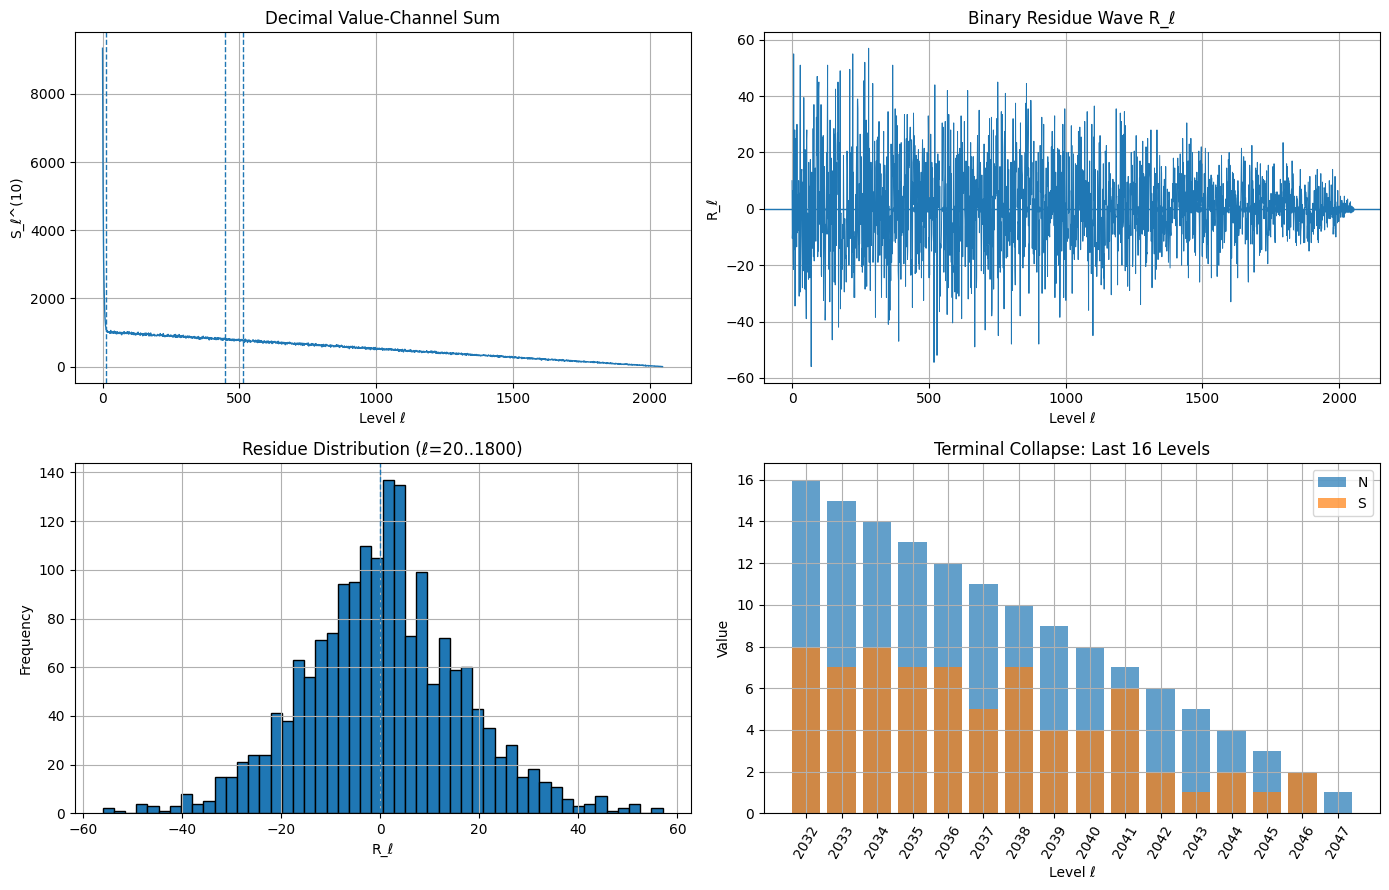

In [17]:
# Cell 16 — Trace plots

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

axes[0,0].plot(decimal_S, linewidth=1)
axes[0,0].axvline(13, linestyle="--", linewidth=1)
axes[0,0].axvline(448, linestyle="--", linewidth=1)
axes[0,0].axvline(512, linestyle="--", linewidth=1)
axes[0,0].set_title("Decimal Value-Channel Sum")
axes[0,0].set_xlabel("Level ℓ")
axes[0,0].set_ylabel("S_ℓ^(10)")

R = binary_trace["R"]
axes[0,1].plot(R, linewidth=0.7)
axes[0,1].scatter(binary_trace["locks"], [0]*len(binary_trace["locks"]), s=12)
axes[0,1].axhline(0, linewidth=1)
axes[0,1].set_title("Binary Residue Wave R_ℓ")
axes[0,1].set_xlabel("Level ℓ")
axes[0,1].set_ylabel("R_ℓ")

segment = R[20:1800]
axes[1,0].hist(segment, bins=50, edgecolor="black")
axes[1,0].axvline(0, linestyle="--", linewidth=1)
axes[1,0].set_title("Residue Distribution (ℓ=20..1800)")
axes[1,0].set_xlabel("R_ℓ")
axes[1,0].set_ylabel("Frequency")

last_levels = list(range(2032, 2048))
axes[1,1].bar([str(l) for l in last_levels], binary_trace["N"][last_levels], alpha=0.7, label="N")
axes[1,1].bar([str(l) for l in last_levels], binary_trace["S"][last_levels], alpha=0.7, label="S")
axes[1,1].set_title("Terminal Collapse: Last 16 Levels")
axes[1,1].set_xlabel("Level ℓ")
axes[1,1].set_ylabel("Value")
axes[1,1].tick_params(axis="x", rotation=60)
axes[1,1].legend()

plt.tight_layout()
plt.show()


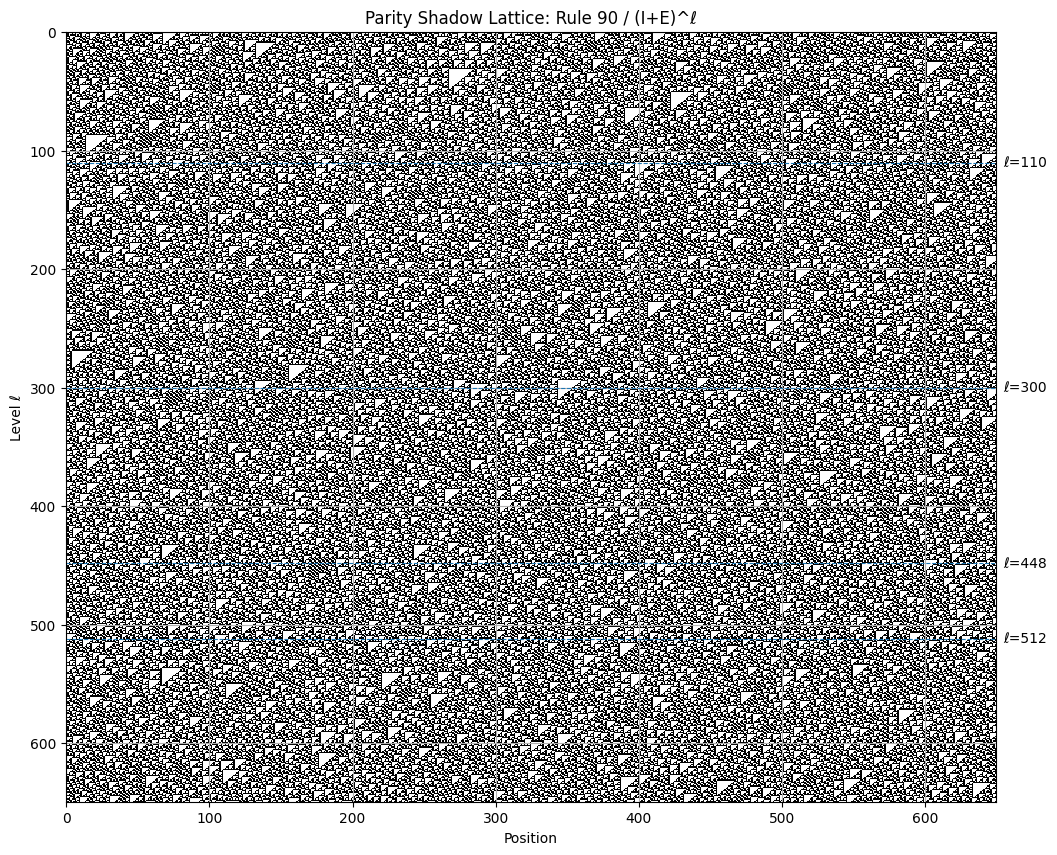

In [18]:
# Cell 17 — Parity lattice crop

max_levels = 650
max_cols = 650

img = np.ones((max_levels, max_cols), dtype=float)
for level in range(max_levels):
    row = xor_lattice[level][:max_cols]
    for i, bit in enumerate(row):
        img[level, i] = 0.0 if bit else 1.0

plt.figure(figsize=(12, 10))
plt.imshow(img, cmap="gray", aspect="auto", interpolation="nearest")
for level in [110, 300, 448, 512]:
    plt.axhline(level, linestyle="--", linewidth=0.8)
    plt.text(max_cols + 5, level, f"ℓ={level}", va="center")
plt.title("Parity Shadow Lattice: Rule 90 / (I+E)^ℓ")
plt.xlabel("Position")
plt.ylabel("Level ℓ")
plt.show()


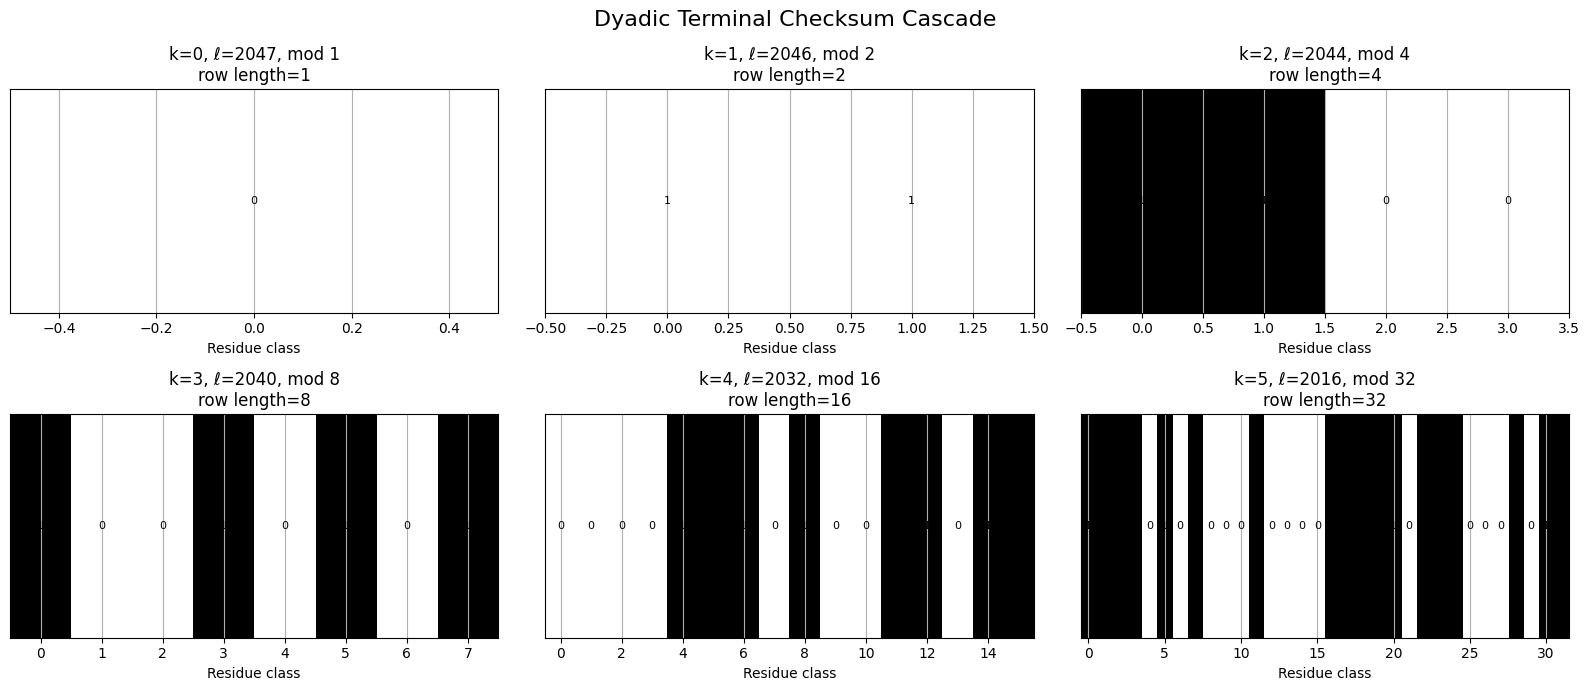

In [19]:
# Cell 18 — Dyadic terminal cascade visualization

fig, axes = plt.subplots(2, 3, figsize=(16, 7))
axes = axes.ravel()

for idx, k in enumerate(range(0, 6)):
    level = N - (1 << k)
    row = xor_lattice[level]
    ax = axes[idx]
    ax.imshow(np.array([row]), cmap="gray_r", aspect="auto", interpolation="nearest")
    ax.set_title(f"k={k}, ℓ={level}, mod {1<<k}\nrow length={len(row)}")
    ax.set_yticks([])
    ax.set_xlabel("Residue class")
    for i, bit in enumerate(row):
        ax.text(i, 0, str(bit), ha="center", va="center", fontsize=8)

plt.suptitle("Dyadic Terminal Checksum Cascade", fontsize=16)
plt.tight_layout()
plt.show()


## 14. Reverse Engine Skeleton

The full decoder target is:

$$
Cx=y
$$

then:

$$
x=x_0+Bz
$$

then:

$$
\operatorname{wt}\left(A_\ell(x_0+Bz)\right)=S_\ell.
$$

The notebook verifies the algebraic carrier and the linear rank collapse:

$$
2048\rightarrow448
$$

remaining degrees of freedom after dyadic terminal tomography plus the $448$ probe.


## 15. Shared Prompt for Other AIs

> We are working under **Nexus Fold Tomography** (`FOLD-TOMO`). This notebook is **FOLD-TOMO-01b: Trace-Sufficient Reverse Fold Engine — Safe Run**. The verified object is the first $2048$ fractional digits of $\pi$ under decimal adjacent-difference reduction. Its parity shadow is exact: $|a-b|\bmod2=a\oplus b$, so the binary fold is Rule 90, $x^{(\ell)}=(I+E)^\ell x^{(0)}$. Lucas's theorem gives $x_i^{(\ell)}=\bigoplus_{j\subseteq\ell}x_{i+j}^{(0)}$. The level $448$ mask is $\{0,64,128,192,256,320,384,448\}$ and the measured row is $N=1600,S=800,R=0$. Terminal rows $\ell=N-2^k$ are dyadic residue-class parity checks. Therefore the fold is a multiscale parity tomography machine. The reverse engine solves linear parity probes first, leaving a structured affine space, then applies nonlinear Hamming-weight constraints $\operatorname{wt}((I+E)^\ell x)=S_\ell$. Keep SHA and Collatz as branch-grammar analogies unless separately proven.


## 16. Final Lock

$$
\Delta:
\text{decimal digits project to parity}
$$

$$
\oplus:
\text{parity becomes Rule 90 / }(I+E)^\ell
$$

$$
↻:
\text{Lucas masks and dyadic terminal rows form tomography probes}
$$

$$
\bot:
\text{row-sum residues break remaining symmetry}
$$

$$
\Psi:
\boxed{
\text{shape can recover location when enough probes are stacked}
}
$$

Notebook name:

$$
\boxed{
\textbf{FOLD-TOMO-01b: Trace-Sufficient Reverse Fold Engine — Safe Run}
}
$$
